In [32]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

import pickle

In [30]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
with open("tokens.pkl", "rb") as f:
    data = pickle.load(f)

print(data["headlines_tokens"][:10])   
print(data["categories"][:5])          


['family', 'generation', 'changer', 'firestorm', 'aol', 'employee', 'benefit', 'cut', 'dakota', 'access']
['IMPACT', 'BUSINESS', 'POLITICS', 'GREEN', 'SCIENCE']


In [6]:
print(type(data))

<class 'dict'>


## Bag of Word Implementation

In [7]:
docs = [
    " ".join(data["headlines_tokens"]),
    " ".join(data["description_tokens"])
]

In [10]:
vectorizer = CountVectorizer()
model_bow = vectorizer.fit_transform(docs)

In [15]:
from itertools import islice

print("Vocabulary:", dict(islice(vectorizer.vocabulary_.items(), 5)))
print("Feature Names:", vectorizer.get_feature_names_out()[:5])
print("Bag of Words Representation:\n", model_bow.toarray()[:5, :5])

Vocabulary: {'family': 6915, 'generation': 7867, 'changer': 3472, 'firestorm': 7216, 'aol': 1364}
Feature Names: ['0000' '002' '007' '01042013' '05152013']
Bag of Words Representation:
 [[0 1 1 0 0]
 [1 0 0 1 1]]


In [23]:
word_counts = np.sum(model_bow.toarray(), axis=0)
words = vectorizer.get_feature_names_out()
df = pd.DataFrame({"words": words, "frequency": word_counts, })

top10_df = df.sort_values(by="frequency", ascending=False).head(10)

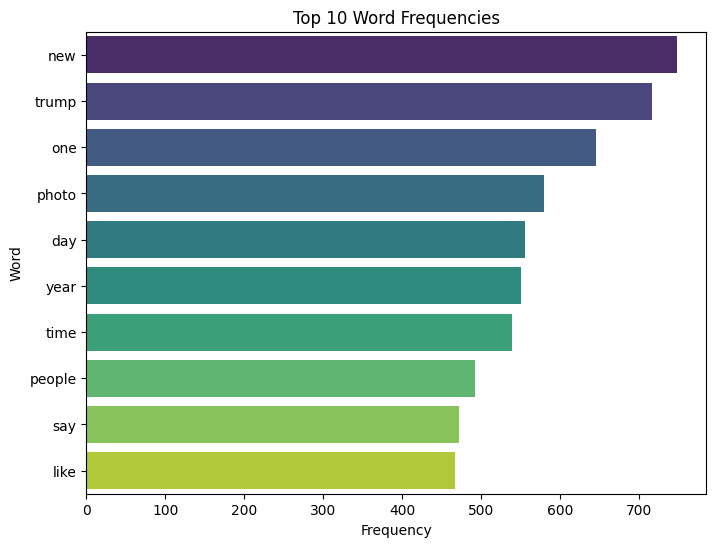

In [31]:
plt.figure(figsize=(8,6))
sns.barplot(x="frequency", y="words", data=top10_df, palette="viridis")

plt.title("Top 10 Word Frequencies")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

## TF-IDF Implementation

In [33]:
tfvectorizer = TfidfVectorizer()
model_tfidf = tfvectorizer.fit_transform(docs)